In [336]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [337]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Phase_diversity_helpers_cupy import *


In [338]:
from scipy.fft import fft2, ifft2
from scipy.fft import fftshift
from scipy.fft import ifftshift

In [339]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = False
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [340]:
N_order = 3              # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                   # Magnification rate from input to objective
w_0 = 3.5                 # mm
three_p_alpha = np.arcsin(num_apt / n)

#50 microns
L_ffp = 0.1065
#512 x 512
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
three_p_microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)

In [341]:
N_order = 1              # 3 for 3P, 2 for 2P
lambd = 5.32e-4             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.2            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                   # Magnification rate from input to objective
w_0 = 3.5                 # mm
one_p_alpha = np.arcsin(num_apt / n)

#50 microns
L_ffp = 0.1065
#512 x 512
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
one_p_microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)

In [ ]:
f = np.load("images/usaf_resolution.npy")

In [312]:
def objective(microscope, D_stack, a_proposed, a_stack, gamma):
    S_stack = cp.stack([
        cp.fft.fft2(forward_PSF(microscope, a_proposed + a))
        for a in a_stack
    ], axis=0)

    first_term = cp.sum(cp.abs(D_stack) ** 2)
    numerator = cp.abs(cp.sum(cp.conj(S_stack) * D_stack, axis=0)) ** 2
    denominator = gamma + cp.sum(cp.abs(S_stack) ** 2, axis=0)

    return float(cp.asnumpy(cp.real(first_term - cp.sum(numerator / denominator))))


In [313]:
microscope = one_p_microscope
alpha = one_p_alpha

rng_np = np.random.default_rng(15)
rng_cp = cp.random.default_rng(15)

true_aberration = Aberration([[2,2], [-2,2]], [0.05, 0.05])
modes_corrected = true_aberration.modes
gamma = 1e-6

In [314]:
bias_modes = [[-2, 2], [0, 2], [2, 2], [0, 4], [-4, 4], [4, 4]]
bias_strength = 0.5
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]

d_stack = [forward_image(microscope, f, true_aberration + a)
    for a in a_stack]
D_stack = cp.fft.fft2(cp.asarray(d_stack), axes=(-2, -1))

In [315]:
mode_1_guesses = np.linspace(0, 0.1, 21)
mode_2_guesses = np.linspace(0, 0.1, 21)

mode_1_guess_grid, mode_2_guess_grid  = np.meshgrid(mode_1_guesses, mode_2_guesses)
loss_grid = np.zeros_like(mode_1_guess_grid)

In [316]:
for i, mode_1_guess in tqdm(enumerate(mode_1_guesses)):
    for j, mode_2_guess in tqdm(enumerate(mode_2_guesses)):
        loss_grid[i, j] = objective(one_p_microscope, 
                                   D_stack,
                                   Aberration(modes_corrected, [mode_1_guess, mode_2_guess]),
                                       a_stack, 
                                   gamma)

0it [00:00, ?it/s]
0it [00:00, ?it/s]
1it [00:00,  6.72it/s]
2it [00:00,  6.70it/s]
3it [00:00,  6.69it/s]
4it [00:00,  6.69it/s]
5it [00:00,  6.68it/s]
6it [00:00,  6.68it/s]
7it [00:01,  6.68it/s]
8it [00:01,  6.67it/s]
9it [00:01,  6.67it/s]
10it [00:01,  6.66it/s]
11it [00:01,  6.66it/s]
12it [00:01,  6.66it/s]
13it [00:01,  6.66it/s]
14it [00:02,  6.66it/s]
15it [00:02,  6.67it/s]
16it [00:02,  6.67it/s]
17it [00:02,  6.66it/s]
18it [00:02,  6.65it/s]
19it [00:02,  6.66it/s]
20it [00:03,  6.66it/s]
21it [00:03,  6.67it/s]
1it [00:03,  3.15s/it]
0it [00:00, ?it/s]
1it [00:00,  6.71it/s]
2it [00:00,  6.70it/s]
3it [00:00,  6.69it/s]
4it [00:00,  6.69it/s]
5it [00:00,  6.68it/s]
6it [00:00,  6.68it/s]
7it [00:01,  6.68it/s]
8it [00:01,  6.68it/s]
9it [00:01,  6.68it/s]
10it [00:01,  6.68it/s]
11it [00:01,  6.68it/s]
12it [00:01,  6.67it/s]
13it [00:01,  6.68it/s]
14it [00:02,  6.66it/s]
15it [00:02,  6.66it/s]
16it [00:02,  6.67it/s]
17it [00:02,  6.67it/s]
18it [00:02,  6.67it/s]
19

In [317]:
from matplotlib import cm

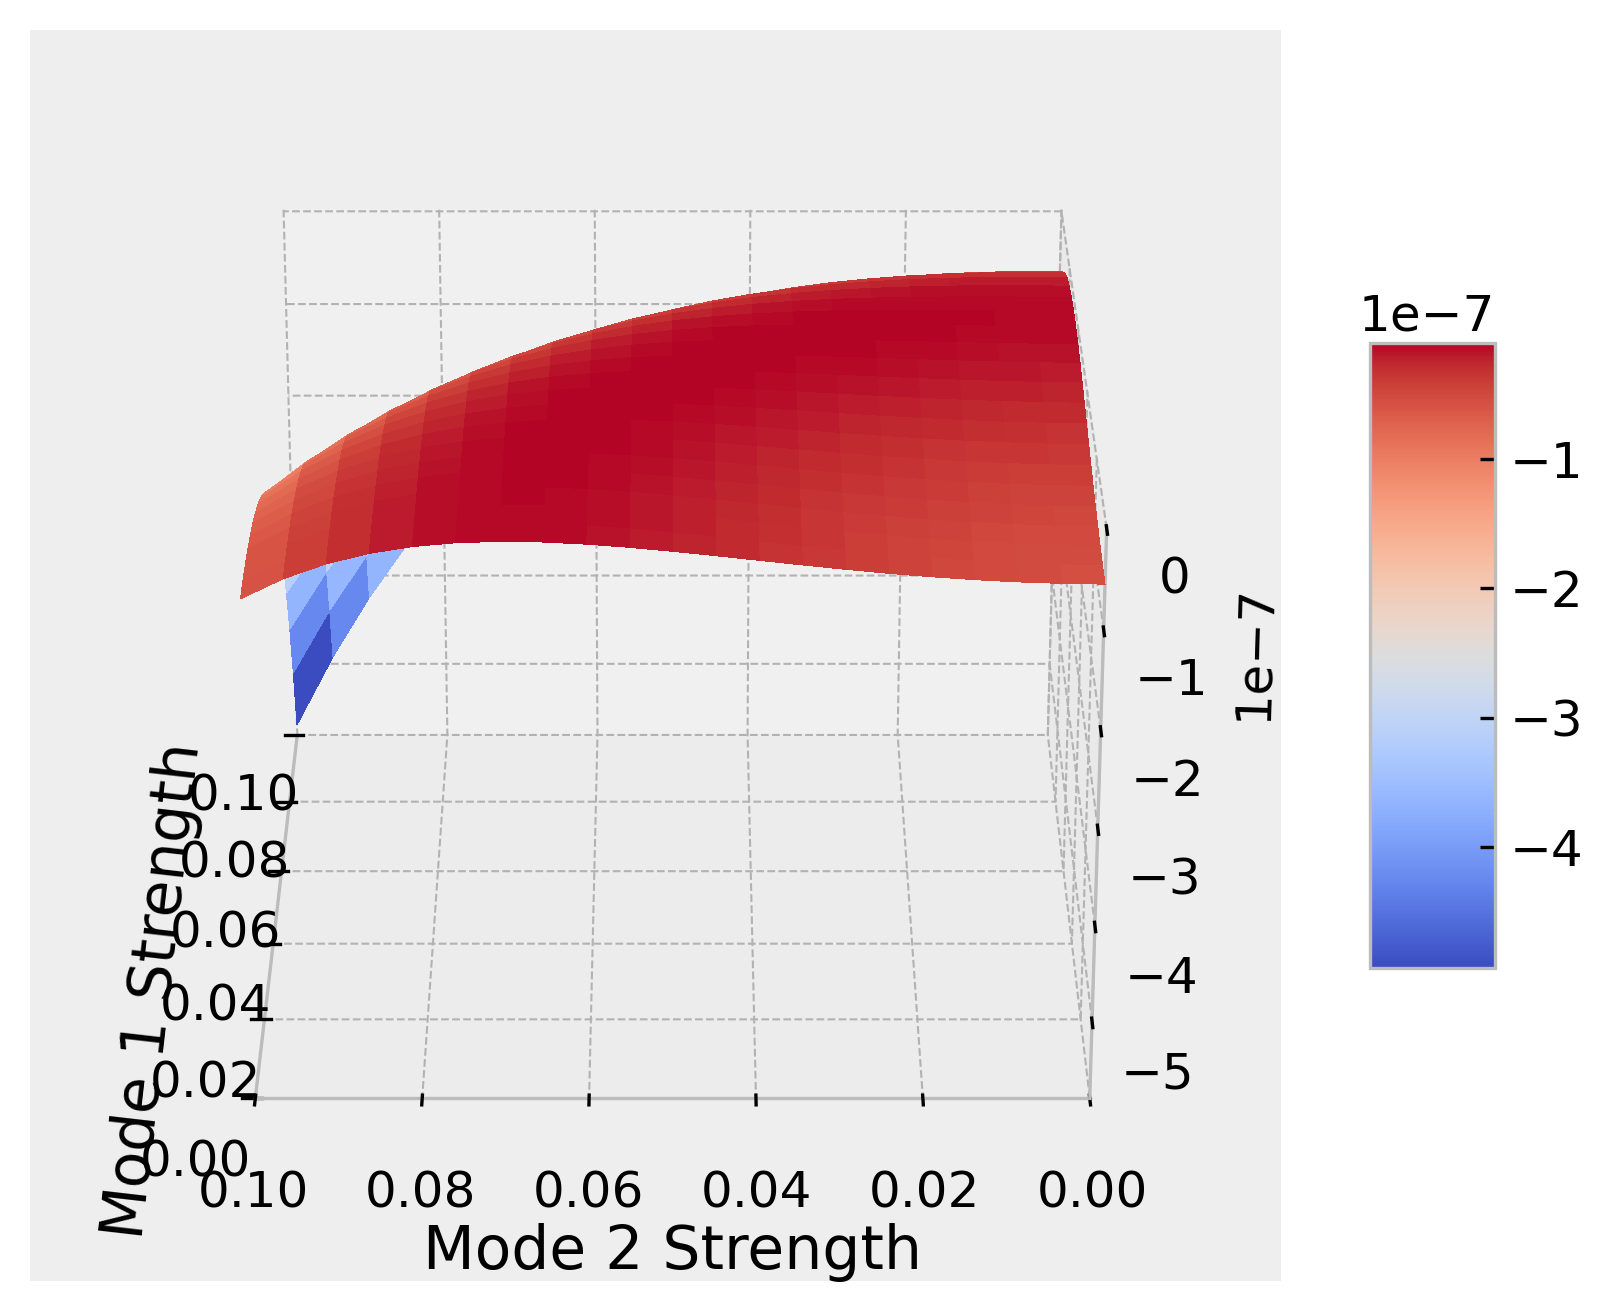

In [335]:
fig, ax = plt.subplots(dpi = 300, subplot_kw={"projection": "3d"})
surf = ax.plot_surface(mode_1_guess_grid, mode_2_guess_grid, -1* loss_grid, cmap = cm.coolwarm,
                       linewidth=0, antialiased=False)
#ax.scatter(0.05, 0.05, -1 * loss_grid[10, 10] + 1000, marker = "x", s = 100)
ax.set_xlabel("Mode 1 Strength")
ax.set_ylabel("Mode 2 Strength")

ax.set_xlim(0, mode_1_guess_grid.max())
ax.set_ylim(0, mode_2_guess_grid.max())

ax.view_init(elev=25, azim=-180)

fig.colorbar(surf, shrink=0.5, aspect=5)

In [319]:
microscope = three_p_microscope
alpha = three_p_alpha

rng_np = np.random.default_rng(15)
rng_cp = cp.random.default_rng(15)

true_aberration = Aberration([[2,2], [-2,2]], [0.05, 0.05])
modes_corrected = true_aberration.modes
gamma = 1e-18

In [326]:
bias_modes = [[-2, 2], [0, 2], [2, 2], [0, 4], [-4, 4], [4, 4]]
bias_strength = 1.0
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]

d_stack = [forward_image(microscope, f, true_aberration + a)
    for a in a_stack]
D_stack = cp.fft.fft2(cp.asarray(d_stack), axes=(-2, -1))

In [327]:
mode_1_guesses = np.linspace(0, 0.1, 21)
mode_2_guesses = np.linspace(0, 0.1, 21)

mode_1_guess_grid, mode_2_guess_grid  = np.meshgrid(mode_1_guesses, mode_2_guesses)
loss_grid = np.zeros_like(mode_1_guess_grid)

In [328]:
for i, mode_1_guess in tqdm(enumerate(mode_1_guesses)):
    for j, mode_2_guess in tqdm(enumerate(mode_2_guesses)):
        loss_grid[i, j] = objective(three_p_microscope, 
                                   D_stack,
                                   Aberration(modes_corrected, [mode_1_guess, mode_2_guess]),
                                       a_stack, 
                                   gamma)

0it [00:00, ?it/s]
0it [00:00, ?it/s]
2it [00:00, 15.48it/s]
4it [00:00, 15.52it/s]
6it [00:00, 15.55it/s]
8it [00:00, 15.56it/s]
10it [00:00, 15.57it/s]
12it [00:00, 15.58it/s]
14it [00:00, 15.59it/s]
16it [00:01, 15.59it/s]
18it [00:01, 15.58it/s]
21it [00:01, 15.57it/s]
1it [00:01,  1.35s/it]
0it [00:00, ?it/s]
2it [00:00, 15.67it/s]
4it [00:00, 15.65it/s]
6it [00:00, 15.63it/s]
8it [00:00, 15.61it/s]
10it [00:00, 15.60it/s]
12it [00:00, 15.59it/s]
14it [00:00, 15.59it/s]
16it [00:01, 15.59it/s]
18it [00:01, 15.59it/s]
21it [00:01, 15.59it/s]
2it [00:02,  1.35s/it]
0it [00:00, ?it/s]
2it [00:00, 15.66it/s]
4it [00:00, 15.63it/s]
6it [00:00, 15.59it/s]
8it [00:00, 15.60it/s]
10it [00:00, 15.61it/s]
12it [00:00, 15.61it/s]
14it [00:00, 15.62it/s]
16it [00:01, 15.61it/s]
18it [00:01, 15.59it/s]
21it [00:01, 15.60it/s]
3it [00:04,  1.35s/it]
0it [00:00, ?it/s]
2it [00:00, 15.68it/s]
4it [00:00, 15.64it/s]
6it [00:00, 15.63it/s]
8it [00:00, 15.63it/s]
10it [00:00, 15.63it/s]
12it [00:00,

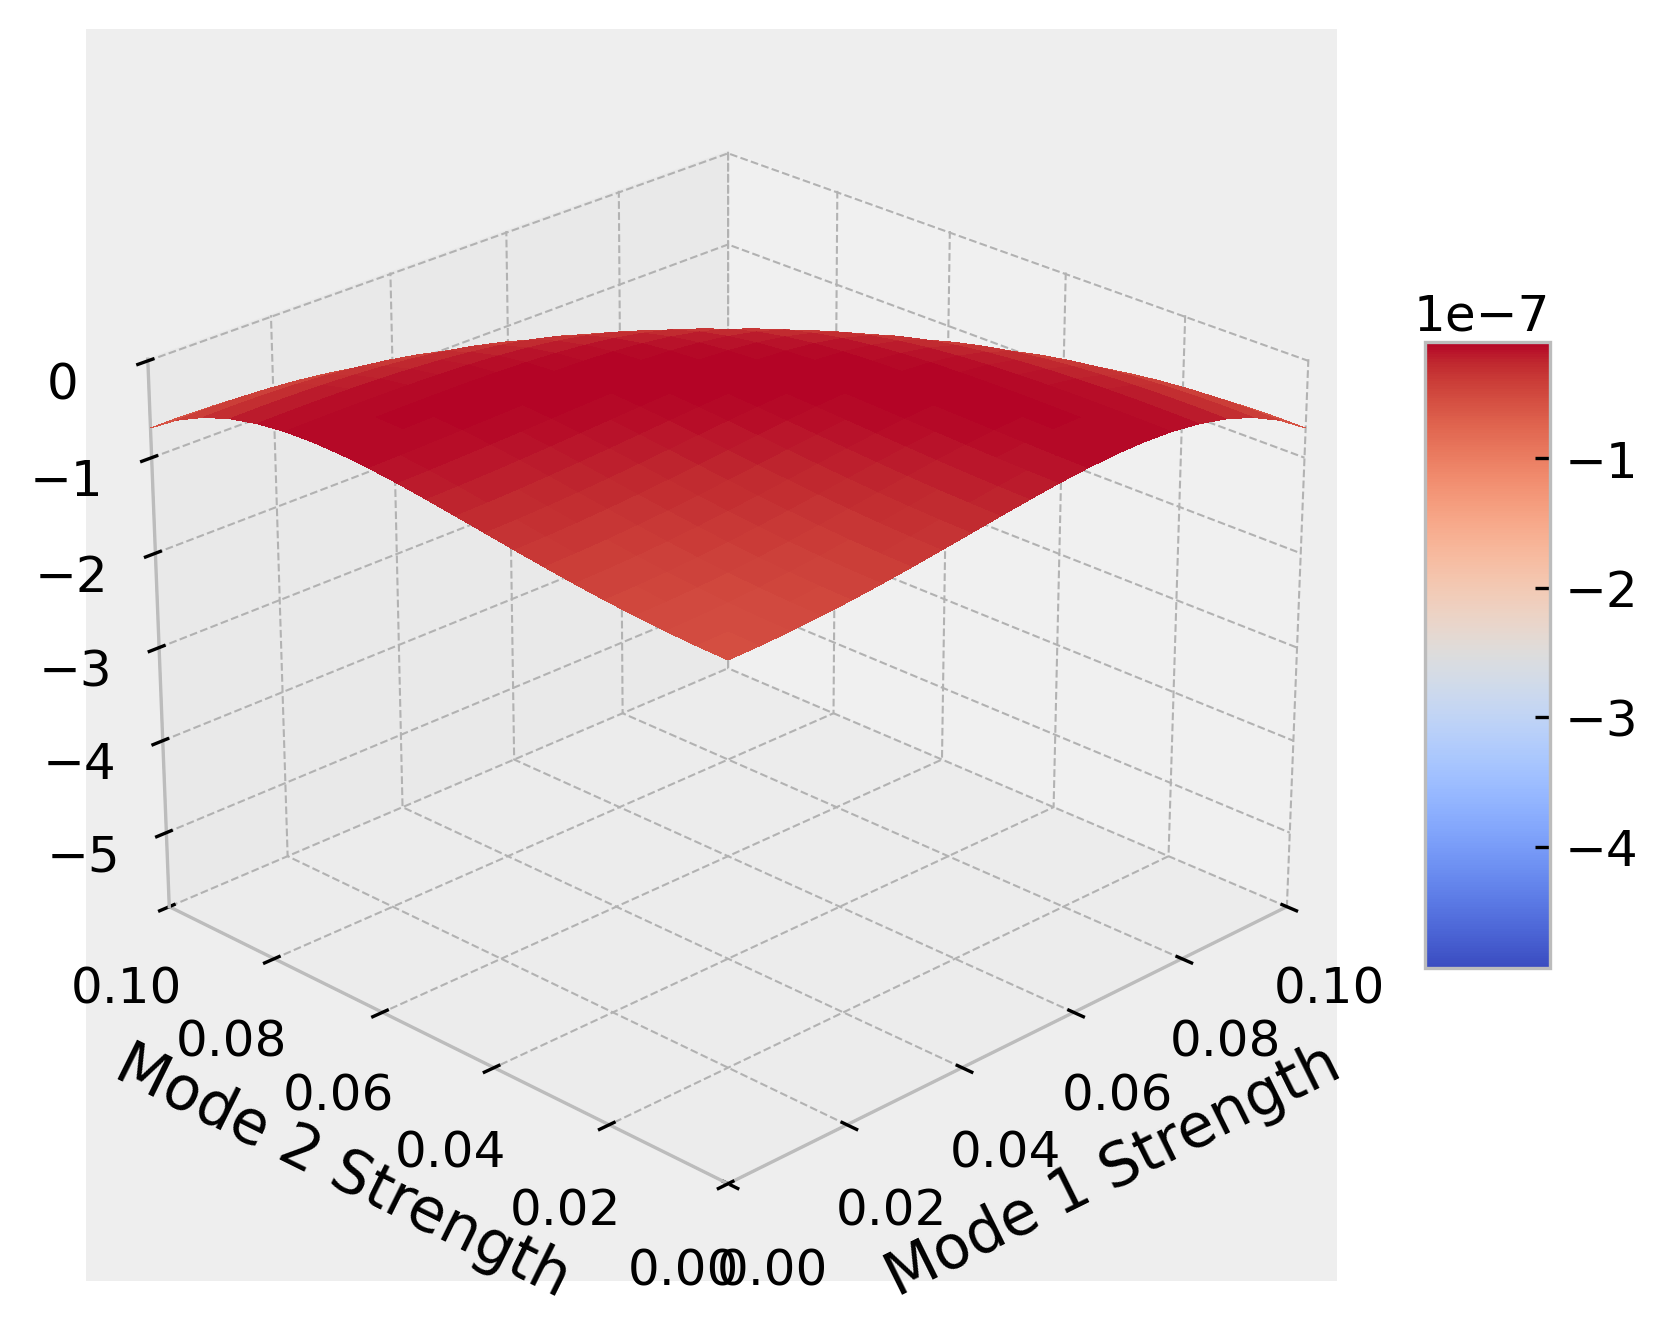

In [343]:
fig, ax = plt.subplots(dpi = 300, subplot_kw={"projection": "3d"})
surf = ax.plot_surface(mode_1_guess_grid, mode_2_guess_grid, -1* (loss_grid), cmap = cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_xlabel("Mode 1 Strength")
ax.set_ylabel("Mode 2 Strength")

ax.set_xlim(0, mode_1_guess_grid.max())
ax.set_ylim(0, mode_2_guess_grid.max())

ax.view_init(elev=25, azim=-135)

fig.colorbar(surf, shrink=0.5, aspect=5)

In [330]:
n_loops = 50
microscope = three_p_microscope
params = {"J_tol": 0.001,
          "max_step": np.inf,
          "gamma": gamma}

loop_optimize(n_loops,
                  microscope,
                  d_stack,
                  a_stack,
                  modes_corrected,
                  params,
                  debug =True,
                  log  =False)

  4%|▍         | 2/50 [00:00<00:05,  8.49it/s]

Loop 1: J = 5.469971872326673e-08
Corrercted Zernike Mode: [[2, 2], [-2, 2]]
Estimated Zernike Coefficients: [0. 0.]
	 Estimated object in 0.002 seconds
	 Estimated gradient in 0.004 seconds
	 Estimated Hessian in 0.039 seconds
Loop 2: J = 2.7874860999282935e-08
Corrercted Zernike Mode: [[2, 2], [-2, 2]]
Estimated Zernike Coefficients: [0.02994837 0.02978877]
	 Estimated object in 0.002 seconds
	 Estimated gradient in 0.004 seconds
	 Estimated Hessian in 0.039 seconds


  8%|▊         | 4/50 [00:00<00:05,  8.50it/s]

Loop 3: J = 1.1334785637862055e-08
Corrercted Zernike Mode: [[2, 2], [-2, 2]]
Estimated Zernike Coefficients: [0.05366932 0.05360775]
	 Estimated object in 0.002 seconds
	 Estimated gradient in 0.003 seconds
	 Estimated Hessian in 0.037 seconds
Loop 4: J = 9.94000036447229e-09
Corrercted Zernike Mode: [[2, 2], [-2, 2]]
Estimated Zernike Coefficients: [0.04967872 0.0495377 ]
	 Estimated object in 0.002 seconds
	 Estimated gradient in 0.003 seconds
	 Estimated Hessian in 0.037 seconds


  8%|▊         | 4/50 [00:00<00:06,  6.81it/s]

Loop 5: J = 9.939625324195678e-09
Corrercted Zernike Mode: [[2, 2], [-2, 2]]
Estimated Zernike Coefficients: [0.04959791 0.04947797]
	 Estimated object in 0.001 seconds
	 Estimated gradient in 0.003 seconds
	 Estimated Hessian in 0.035 seconds


(array([0.04959773, 0.04947791]),
 array([[37917.91587771+0.00000000e+00j,  -314.98802242-2.31290076e+03j,
         -8775.17526599-1.78884179e+03j, ...,
         -6860.73976318-4.74569584e+03j, -8775.17526599+1.78884179e+03j,
          -314.98802242+2.31290076e+03j],
        [-3583.41213331-1.86740245e+03j, -1295.0462637 +6.62741717e+03j,
          1094.52369087-1.91930047e+03j, ...,
          1881.49021128+1.08763297e+03j,  -490.93548615+1.60249856e+02j,
           345.27875772+8.72228229e+02j],
        [-6951.54741146+3.01886503e+03j, -1249.89318054+1.59702646e+03j,
          1030.85341314-5.71961611e+00j, ...,
           667.87707213+1.62539059e+03j, -1041.79505864-2.18752363e+03j,
          3198.62820555+8.84011209e+02j],
        ...,
        [-9043.21425775-6.66457708e+03j,  3818.2412273 +9.27681393e+02j,
         -1353.00323361+5.67709841e+02j, ...,
           211.544957  +2.95053439e+03j,  3772.49219201-3.44581239e+03j,
          1117.29216715+4.59963271e+03j],
        [-6951.54